In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb

from xgboost import plot_importance
from sklearn.inspection import permutation_importance
#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner, Boost_model, ShapAnalysis
from scripts.feat_eng2 import Feature_Engineering
from scripts.feat_eng import apply_all

warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

#싸이킷런에서 인코딩 후 데이터를 판다스 데이터 프레임으로 남기기
set_config(transform_output="pandas")

In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

# Feature Engineering

Feature_Engineering 사용법
=============================

### object 생성
* ```FE = Feature_Engineering(merchant_df, sale_df, cust_df,prediction_month)```

    - prediction_month: n달 이후 폐업 여부를 예측 

### Feature Engineering 실행
* ```FE.run(percent = 0.995,data_select='part',months=[3,6],lag_periods=[1,3,6,12])```

    - 기본적으로 변수들은 기본 지정이 되어 있어서 따로 명시하지 않아도 됨 => FE.run() 기본 설정대로 실행됨
    - percent: 동일 업종 매출금액 비율,동일 업종 매출건수 비율의 상위% 이상치 제거, 기본값 0.995 (상위 0.5%)
    - data_select: 학습 데이터 정의, 문자열로 입력할 것, 기본값: 'part'
        + part: 폐업한 가맹점들 중 폐업 n 전 데이터가 있는 가맹점 데이터
        + base: 폐업한 가맹점 데이터(폐업 n 전 데이터가 없어도 포함)
        + all: 모든 가맹점 데이터 
        + not: 폐업 하지 않은 가맹점 데이터 

    - months: 이동 평균의 기준이 되는 데이터, 기본값: [3,6] (최근 3,6 개월 전 이동 평균)
        + list로 입력할 것
    - lag_periods: ~전 시차 데이터, 기본값: [1,3,6,12] (1,3,6,12 개월 전 데이터)
        + list로 입력할 것

### 인스턴스 변수 출력
* ```FE.merchant_df```
    - merchant_df 값 반환
* ```FE.sale_df```
    - sale_df 값 반환
* ```FE.cust_df```
    - cust_df 값 반환
* ```FE.prediction_month```
    - prediction_month 값 반환



In [4]:
FE = Feature_Engineering(merchant_df, sale_df, cust_df,9)
final_df = FE.run()
final_df_all = Feature_Engineering(merchant_df, sale_df, cust_df,9).run(data_select='all')
final_df_base = Feature_Engineering(merchant_df, sale_df, cust_df,9).run(data_select='base')
final_df_not = Feature_Engineering(merchant_df, sale_df, cust_df,9).run(data_select='not')

In [5]:
final_df

,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,폐업 예측,최근 3개월 평균_매출금액 구간,최근 3개월 평균_매출건수 구간,최근 3개월 평균_유니크 고객 수 구간,최근 3개월 평균_객단가 구간,최근 3개월 평균_동일 업종 매출금액 비율,최근 3개월 평균_동일 업종 매출건수 비율,최근 3개월 평균_동일 업종 내 매출 순위 비율,최근 3개월 평균_동일 상권 내 매출 순위 비율,최근 6개월 평균_매출금액 구간,최근 6개월 평균_매출건수 구간,최근 6개월 평균_유니크 고객 수 구간,최근 6개월 평균_객단가 구간,최근 6개월 평균_동일 업종 매출금액 비율,최근 6개월 평균_동일 업종 매출건수 비율,최근 6개월 평균_동일 업종 내 매출 순위 비율,최근 6개월 평균_동일 상권 내 매출 순위 비율,1개월전_매출금액 구간,3개월전_매출금액 구간,6개월전_매출금액 구간,12개월전_매출금액 구간,1개월전_매출건수 구간,3개월전_매출건수 구간,6개월전_매출건수 구간,12개월전_매출건수 구간,1개월전_유니크 고객 수 구간,3개월전_유니크 고객 수 구간,6개월전_유니크 고객 수 구간,12개월전_유니크 고객 수 구간,1개월전_객단가 구간,3개월전_객단가 구간,6개월전_객단가 구간,12개월전_객단가 구간,업종,상권
1,4.0,4.0,4.0,4.0,43.7,23.3,34.1,0.0,0,4.0,4.0,4.0,4.0,51.350000,22.100000,33.950000,0.000000,4.0,4.0,4.0,4.0,51.350000,22.100000,33.950000,0.000000,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,육류,왕십리
2,4.0,4.0,4.0,3.0,52.2,22.3,34.8,0.0,0,4.0,4.0,4.0,3.0,51.633333,22.166667,34.233333,0.000000,4.0,4.0,4.0,3.0,51.633333,22.166667,34.233333,0.000000,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,육류,왕십리
3,5.0,4.0,4.0,3.0,32.5,15.1,36.9,0.0,0,4.0,4.0,4.0,3.0,42.800000,20.233333,35.266667,0.000000,4.0,4.0,4.0,3.0,46.850000,20.400000,34.900000,0.000000,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,3.0,NaN,NaN,육류,왕십리
4,4.0,4.0,4.0,3.0,50.1,23.3,37.7,0.0,0,4.0,4.0,4.0,3.0,44.933333,20.233333,36.466667,0.000000,4.0,4.0,4.0,3.0,47.500000,20.980000,35.460000,0.000000,5.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,4.0,NaN,NaN,육류,왕십리
5,4.0,4.0,4.0,3.0,55.5,24.1,38.2,0.0,0,4.0,4.0,4.0,3.0,46.033333,20.833333,37.600000,0.000000,4.0,4.0,4.0,3.0,48.833333,21.500000,35.916667,0.000000,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,3.0,NaN,NaN,육류,왕십리
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2253,3.0,1.0,1.0,5.0,202.4,332.7,5.7,28.6,0,3.0,1.0,1.0,5.0,222.300000,383.433333,5.800000,28.600000,2.0,1.0,1.0,5.0,246.283333,430.266667,5.616667,28.000000,3.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,6.0,5.0,6.0,카페,한양대
2254,2.0,1.0,1.0,5.0,240.0,407.6,5.6,28.3,0,3.0,1.0,1.0,5.0,209.666667,355.833333,5.733333,28.633333,2.0,1.0,1.0,5.0,244.466667,424.900000,5.666667,28.250000,3.0,2.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,6.0,카페,한양대
2255,2.0,1.0,1.0,5.0,275.2,449.2,5.4,27.8,0,2.0,1.0,1.0,5.0,239.200000,396.500000,5.566667,28.233333,2.0,1.0,1.0,5.0,241.350000,414.883333,5.666667,28.333333,2.0,3.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,6.0,카페,한양대
2256,3.0,1.0,1.0,6.0,200.1,360.9,5.6,27.1,0,2.0,1.0,1.0,5.0,238.433333,405.900000,5.533333,27.733333,2.0,1.0,1.0,5.0,230.366667,394.666667,5.666667,28.166667,2.0,3.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,6.0,5.0,카페,한양대


In [6]:
#Target 수
print(final_df['폐업 예측'].sum())

363


ModelTuner 사용법
=================

### 사용가능한 모델
* logistic, knn, gnb, svc_linear, svc_rbf, xgb, lgbm

### 모델 생성 및 데이터 입력
* ```MT = ModelTuner(Model,X_train, X_test,y_train,y_test)```
* Model: 위 모델명을 문자열로 입력할 것
* 예시
    - ```logistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)```
    - ```xgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)```

### 모델 튜닝 및 평가
* ```MT.run(tune_evals=50)```
* tune_evals은 생략 가능
* 예시
    - ```logistic_tuner.run(tune_evals=50)```

### 튜닝된 모델
* ```tuned_model = MT.final_model()```
* 예시
    - ```logistic_tuner.final_model()```

### 최적의 파라미터
* ```best_parameter = MT.best_params()```
* 예시
    - ```logistic_tuner.best_params()```

### 모델 성능 지표
* ```eval = MT.evaluate()```
* 예시
    - ```logistic_tuner.evaluate()```

### 인코딩

# DataProcessor 사용법

### 기능
    - 타겟 분리, 인코딩, 학습, 테스트, 검증 데이터 분리

### 객체 생성
```df_part = DataProcessor(final_df)```

### 클래스 작동
```
df_part.process()
```

### 인스턴스 변수
```
df_part.X_train
df_part.X_test 
df_part.y_train 
df_part.y_test 
df_part.X_tr 
df_part.X_val 
df_part.y_tr 
df_part.y_val 
```

### 학습,테스트 데이터 세트

* 학습 데이터 세트
    - X_train, y_train 묶음 대체
        ```
        X_train ,y_train = df_part.Train()

        lr = LogisticRegression()
        lr.fit(X_train, y_train)
        lr.fit(df_part.Train())
        ```

* 테스트 데이터 세트
    - X_test, y_test 묶음 대체
        ```
        X_test, y_test = df_part.Test()

        model_eval(lr,"Logistic Regression",X_test, y_test)
        model_eval(lr,"Logistic Regression",df_part.Test())
        ```

* 학습 & 테스트 데이터 세트
    - X_train, X_test, y_train, y_test 묶음 대체
        ```
        X_train, X_test,y_train,y_test = df_part.Xtr_yte()

        LRT = ModelTuner('logistic',X_train, X_test,y_train,y_test)
        LRT = ModelTuner('logistic',df_part.Xtr_yte())
        ```


In [7]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2145 entries, 1 to 2257
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   매출금액 구간                     2145 non-null   float64
 1   매출건수 구간                     2145 non-null   float64
 2   유니크 고객 수 구간                 2145 non-null   float64
 3   객단가 구간                      2145 non-null   float64
 4   동일 업종 매출금액 비율               2145 non-null   float64
 5   동일 업종 매출건수 비율               2145 non-null   float64
 6   동일 업종 내 매출 순위 비율            2145 non-null   float64
 7   동일 상권 내 매출 순위 비율            2145 non-null   float64
 8   폐업 예측                       2145 non-null   int64  
 9   최근 3개월 평균_매출금액 구간           2145 non-null   float64
 10  최근 3개월 평균_매출건수 구간           2145 non-null   float64
 11  최근 3개월 평균_유니크 고객 수 구간       2145 non-null   float64
 12  최근 3개월 평균_객단가 구간            2145 non-null   float64
 13  최근 3개월 평균_동일 업종 매출금액 비율     2145 non-n

In [8]:
#인코딩 결과를 객체로 저장

class DataProcessor:

    def __init__(self, final_df: pd.DataFrame):
        self.final_df = final_df.copy()
        self.preprocessor = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X_tr = None
        self.X_val = None
        self.y_tr = None
        self.y_val = None

    def process(self):

        y = self.final_df['폐업 예측']
        X = self.final_df.drop(columns=['폐업 예측'])

        X_train_raw, X_test_raw, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        
        numerical_features_log = [
            '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
            '최근 3개월 평균_동일 업종 매출금액 비율', '최근 3개월 평균_동일 업종 매출건수 비율',
            '최근 6개월 평균_동일 업종 매출금액 비율', '최근 6개월 평균_동일 업종 매출건수 비율']
        
        categorical_features = X_train_raw.select_dtypes(exclude=['int64', 'float64']).columns

        
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num_log', FunctionTransformer(np.log1p), numerical_features_log), # 일부 피쳐는 log 변환
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # 범주형 피쳐는 OneHotEncoding
            ],
            remainder='passthrough')  # 위에서 지정하지 않은 나머지 피처는 그대로 통과
        
        self.X_train = self.preprocessor.fit_transform(X_train_raw)
        self.X_test = self.preprocessor.transform(X_test_raw)
        
        self.X_tr, self.X_val, self.y_tr, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train)
        
        print(f"X_train shape: {self.X_train.shape}")
        print(f"X_test shape: {self.X_test.shape}")
        print(f"X_val shape: {self.X_val.shape}")

        return self
        
    def Train(self):
        if self.X_train is None:
            raise ValueError("학습,테스트,검증 세트를 분리 과정이 필요합니다: process()") 
        
        return self.X_train,self.y_train

    def Test(self):
        if self.X_train is None:
            raise ValueError("학습,테스트,검증 세트를 분리 과정이 필요합니다: process()") 
        
        return self.X_test,self.y_test
        
    def Xtr_yte(self):
        if self.X_train is None:
            raise ValueError("학습,테스트,검증 세트를 분리 과정이 필요합니다: process()") 
        
        return self.X_train,self.X_test,self.y_train,self.y_test
    


        

In [9]:
df_part = DataProcessor(final_df).process()
df_all = DataProcessor(final_df_all).process()
df_base = DataProcessor(final_df_base).process()
df_not = DataProcessor(final_df_not).process()

X_train shape: (1716, 63)
X_test shape: (429, 63)
X_val shape: (344, 63)
X_train shape: (65261, 63)
X_test shape: (16316, 63)
X_val shape: (13053, 63)
X_train shape: (1757, 63)
X_test shape: (440, 63)
X_val shape: (352, 63)
X_train shape: (63504, 63)
X_test shape: (15876, 63)
X_val shape: (12701, 63)


In [10]:
df_part.X_train

,num_log__동일 업종 매출금액 비율,num_log__동일 업종 매출건수 비율,num_log__최근 3개월 평균_동일 업종 매출금액 비율,num_log__최근 3개월 평균_동일 업종 매출건수 비율,num_log__최근 6개월 평균_동일 업종 매출금액 비율,num_log__최근 6개월 평균_동일 업종 매출건수 비율,cat__업종_간편식,cat__업종_기타,cat__업종_농수축산물,cat__업종_디저트,cat__업종_양식,cat__업종_유흥업소,cat__업종_육류,cat__업종_이색요리,cat__업종_일식,cat__업종_주점,cat__업종_중식,cat__업종_카페,cat__업종_한식,cat__상권_금남시장,cat__상권_답십리,cat__상권_뚝섬,cat__상권_마장동,cat__상권_성수,cat__상권_신금호,...,remainder__최근 3개월 평균_객단가 구간,remainder__최근 3개월 평균_동일 업종 내 매출 순위 비율,remainder__최근 3개월 평균_동일 상권 내 매출 순위 비율,remainder__최근 6개월 평균_매출금액 구간,remainder__최근 6개월 평균_매출건수 구간,remainder__최근 6개월 평균_유니크 고객 수 구간,remainder__최근 6개월 평균_객단가 구간,remainder__최근 6개월 평균_동일 업종 내 매출 순위 비율,remainder__최근 6개월 평균_동일 상권 내 매출 순위 비율,remainder__1개월전_매출금액 구간,remainder__3개월전_매출금액 구간,remainder__6개월전_매출금액 구간,remainder__12개월전_매출금액 구간,remainder__1개월전_매출건수 구간,remainder__3개월전_매출건수 구간,remainder__6개월전_매출건수 구간,remainder__12개월전_매출건수 구간,remainder__1개월전_유니크 고객 수 구간,remainder__3개월전_유니크 고객 수 구간,remainder__6개월전_유니크 고객 수 구간,remainder__12개월전_유니크 고객 수 구간,remainder__1개월전_객단가 구간,remainder__3개월전_객단가 구간,remainder__6개월전_객단가 구간,remainder__12개월전_객단가 구간
1183,5.437209,5.737862,5.445731,5.731290,5.425280,5.732613,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,7.100000,12.566667,2.0,2.0,2.0,3.0,7.075000,12.550000,2.0,2.0,NaN,NaN,2.0,2.0,NaN,NaN,2.0,2.0,NaN,NaN,3.0,3.0,NaN,NaN
602,5.262172,6.799502,5.154255,6.496976,5.037061,6.115451,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,12.033333,44.766667,3.0,2.0,2.0,5.0,13.183333,45.000000,3.0,3.0,3.0,NaN,2.0,2.0,1.0,NaN,2.0,2.0,1.0,NaN,5.0,5.0,5.0,NaN
44,5.330785,5.910254,5.473950,6.107542,5.470799,6.137403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,4.0,7.933333,0.000000,2.0,1.0,1.0,4.0,8.000000,0.000000,2.0,2.0,NaN,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN,4.0,4.0,NaN,NaN
2213,4.667206,4.458988,3.690545,3.509553,3.633631,3.500288,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,4.0,38.266667,0.000000,4.0,4.0,4.0,4.0,38.575000,0.000000,5.0,4.0,NaN,NaN,5.0,4.0,NaN,NaN,5.0,4.0,NaN,NaN,3.0,3.0,NaN,NaN
1652,3.481240,5.190732,3.595484,5.242981,3.582593,5.228431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,39.933333,40.666667,4.0,3.0,3.0,5.0,39.050000,39.633333,4.0,4.0,4.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,5.0,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,5.611667,5.877736,5.487007,5.717028,5.479180,5.721841,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,5.0,6.266667,17.433333,3.0,1.0,1.0,5.0,6.300000,16.800000,3.0,3.0,3.0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,5.0,5.0,5.0,NaN
1499,5.518256,6.432297,5.457598,6.408748,5.422671,6.370243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,4.0,6.533333,10.466667,2.0,1.0,1.0,4.0,6.350000,10.233333,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,4.0,4.0,4.0
1446,4.446174,4.782479,4.358417,4.684289,4.532779,4.513420,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,21.233333,0.000000,3.0,3.0,3.0,3.0,14.533333,0.000000,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
1245,3.580737,2.468100,4.065030,2.901422,4.181796,2.937397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,19.000000,22.266667,4.0,5.0,5.0,1.0,17.666667,21.350000,4.0,4.0,3.0,3.0,5.0,5.0,4.0,4.0,5.0,5.0,4.0,4.0,1.0,1.0,1.0,1.0


### Logistic Regression

In [32]:
#Logistic Regression
lr = LogisticRegression()
lr.fit(df_part.Train())

model_eval(lr,"Logistic Regression",df_part.Test())

TypeError: LogisticRegression.fit() missing 1 required positional argument: 'y'

In [ ]:
LRT = ModelTuner('logistic',df_part.Xtr_yte())
LRT.run()

--- logistic 모델의 하이퍼파라미터 튜닝 시작 ---
 30%|███       | 15/50 [00:26<01:28,  2.53s/trial, best loss: -0.5842857142857143]

### Gaussian Naive Bayes

In [ ]:
# Gaussian Naive Bayes
gnb=GaussianNB()
gnb.fit(X_train,y_train)

#가우시안은 X 데이터에 .toarray() 붙이기
model_eval(gnb,"Gaussian Naive Bayes",X_test,y_test)

In [ ]:
GNBT = ModelTuner('gnb',X_train, X_test,y_train,y_test)
GNBT.run()

### KNN(K-Nearest Neighbours)

In [ ]:
#K-Nearest Neighbours(KNN)
knn=KNeighborsClassifier() 
knn.fit(X_train,y_train)

model_eval(knn,"K-Nearest Neighbours",X_test,y_test)

In [ ]:
#KNN 모델에서 N-neighbours 수를 늘려가며 정확도를 계산
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    knnn=KNeighborsClassifier(n_neighbors=i) 
    knnn.fit(X_train,y_train)
    prediction=knnn.predict(X_test)
    score = pd.Series([metrics.accuracy_score(prediction,y_test)])
    a = pd.concat([a, score], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

In [ ]:
KNNT = ModelTuner('knn',X_train, X_test,y_train,y_test)
KNNT.run()

### Support Vector Machine

In [ ]:
#Linear Support Vector Machine(linear-SVM)
svcl=svm.SVC(probability=True,kernel='linear',C=0.1,gamma=0.1)
svcl.fit(X_train,y_train)

model_eval(svcl,"Linear Support Vector Machine",X_test,y_test)

In [ ]:
SVMT = ModelTuner('svc_linear',X_train, X_test,y_train,y_test)
SVMT.run()

In [ ]:
#Radial Support Vector Machines(rbf-SVM)
svcr=svm.SVC(probability=True,kernel='rbf',C=1,gamma=0.1)
svcr.fit(X_train,y_train)

model_eval(svcr,"Radial Support Vector Machines",X_test,y_test)

In [ ]:
SVMT2 = ModelTuner('svc_rbf',X_train, X_test,y_train,y_test)
SVMT2.run()

BOOST MODEL
=============

## Boost_model 사용법

### 객체 생성
* XGB 모델 객체: ```xgb_obj = Boost_model('xgb',train_data)```
* LBBM 모델 객체: ```lgb_obj = Boost_model('lgbm',train_data)```
* *주의: train_data는 DataProcessor로 생성된 객체이어야 함*

### 인스턴스 변수
* ```xgb_obj.train_data```: 입력한 train_data 반환
* ```xgb_obj.model_type```: 부스트 모델 종류 반환 (xgb,lgbm)
* ```xgb_obj.model```: XGB 모델 반환
* ```lgb_obj.model```: LBBM 모델 반환
* 그외에 XGB,LBBM 모델의 parameter도 정의되어 있음 후술 (ex. n_estimators, learning_rate 등)

### 모델 학습
```
xgb_obj.fit()
lgb_obj.fit()
```

### 모델 평가
```
xgb_obj.evaluation()
lgb_obj.evaluation()
```
* 모델 평가는 모델 학습도 자동 실행 *(모델 학습 후에 평가를 실행하지 말 것)*

### Feature Importance
```
xgb_obj.plot_feature_importance()
lgb_obj.plot_feature_importance()
```
* *모델 학습 후에 실행 할 것*

### Permutation Importance
```
xgb_obj.permutation_importance_plot()
lgb_obj.permutation_importance_plot()
```
* *모델 학습 후에 실행 할 것*

### 생략된 parameter
```
Boost_model(model_type: str,train_data,GPU ='off',
    early_stopping_rounds = 50,n_estimators=500,learning_rate=0.05,
    min_gain_to_split=0.05, subsample=0.8,colsample_bytree=0.8, random_state=42)
```


### Light Gradient Boosting Machine

In [ ]:
'''
df_part 
df_all 
df_base 
df_not 
'''

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] Number of positive: 232, number of negative: 1140
[LightGBM] [Info] Total Bins 3301
[LightGBM] [Info] Number of data points in the train set: 1372, number of used features: 61
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 r

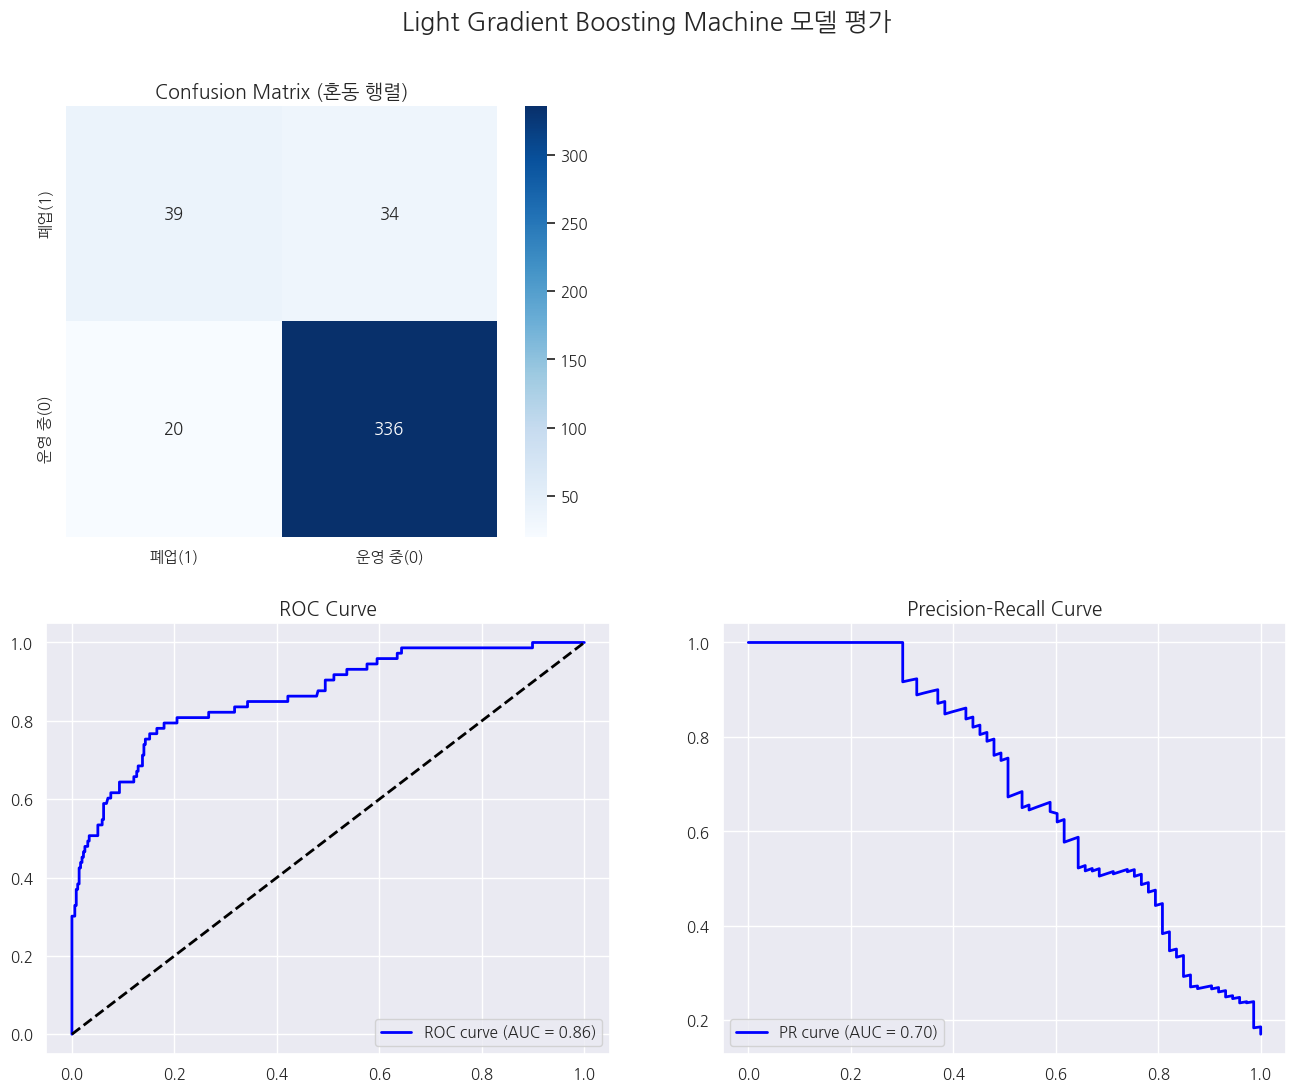

In [10]:
lgb_obj = Boost_model('lgbm',df_part,GPU = 'on')
lgb_obj.evaluation()


--- 데이터 인덱스 300번 샘플에 대한 분석을 시작합니다. ---
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05

예측 기여도 텍스트 요약
🎯 가맹점이 폐업할 예측 확률: 0.7649

📊 모델의 평균 예측 기준값 (Base Value): -1.0422

폐업 예측 요인 TOP 5 피쳐:
                                  Feature  SHAP Value (기여도)
62                remainder__12개월전_객단가 구간          0.799548
53                remainder__6개월전_매출건수 구간          0.526882
58           remainder__12개월전_유니크 고객 수 구간          0.424078
45  remainder__최근 6개월 평균_동일 업종 내 매출 순위 비율          0.287961
50               remainder__12개월전_매출금액 구간          0.268316

>>> 4-3. Custom Bar Plot (폐업 예측 긍정 영향 TOP 5)


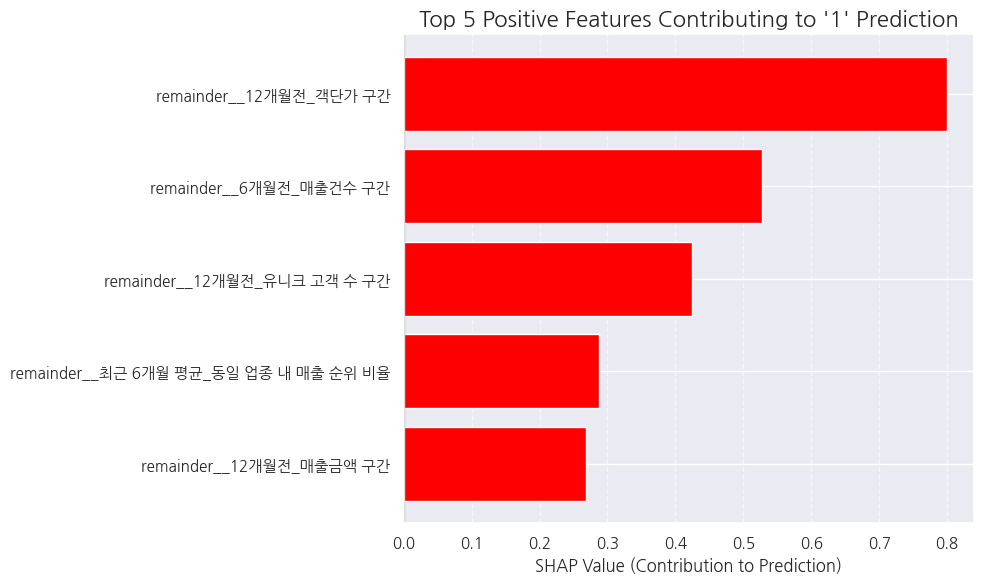


>>>Force Plot (단일 데이터 예측 설명)



>>>Summary Plot (전체 특성 중요도)


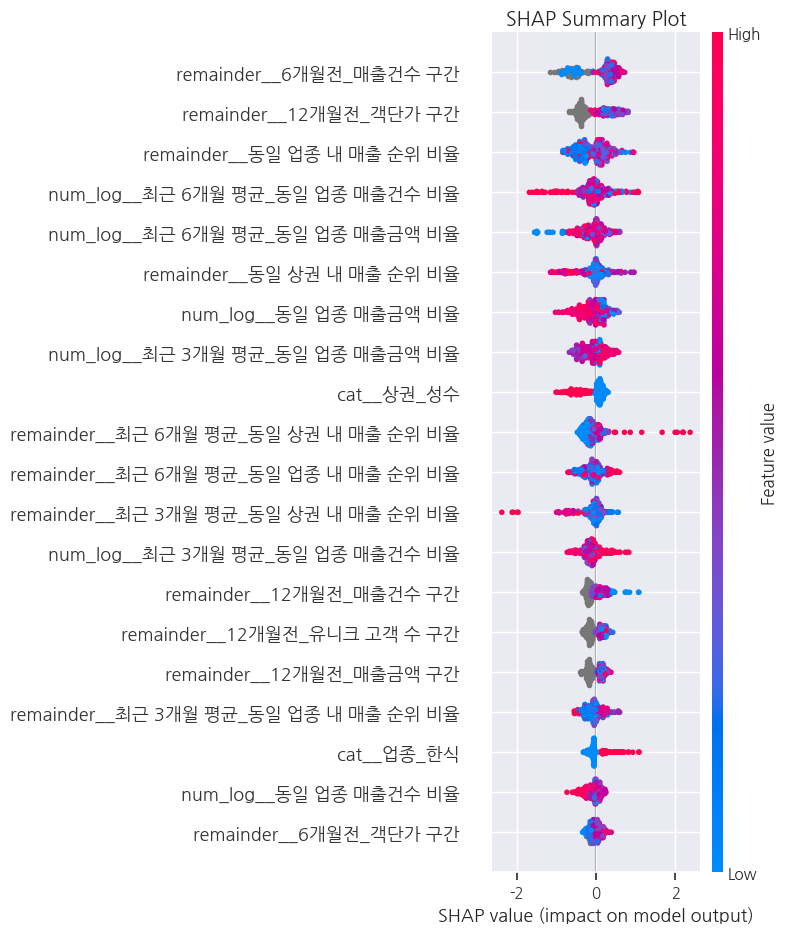

In [13]:
SA1 = ShapAnalysis(lgb_obj.model,df_part)
SA1.single_sample_analysis(index = 300)
SA1.summary_plot()

In [ ]:
#shap으로 피쳐 분석 가능


[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] Number of positive: 266, number of negative: 51942
[LightGBM] [Info] Total Bins 3314
[LightGBM] [Info] Number of data points in the train set: 52208, number of used features: 63
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 

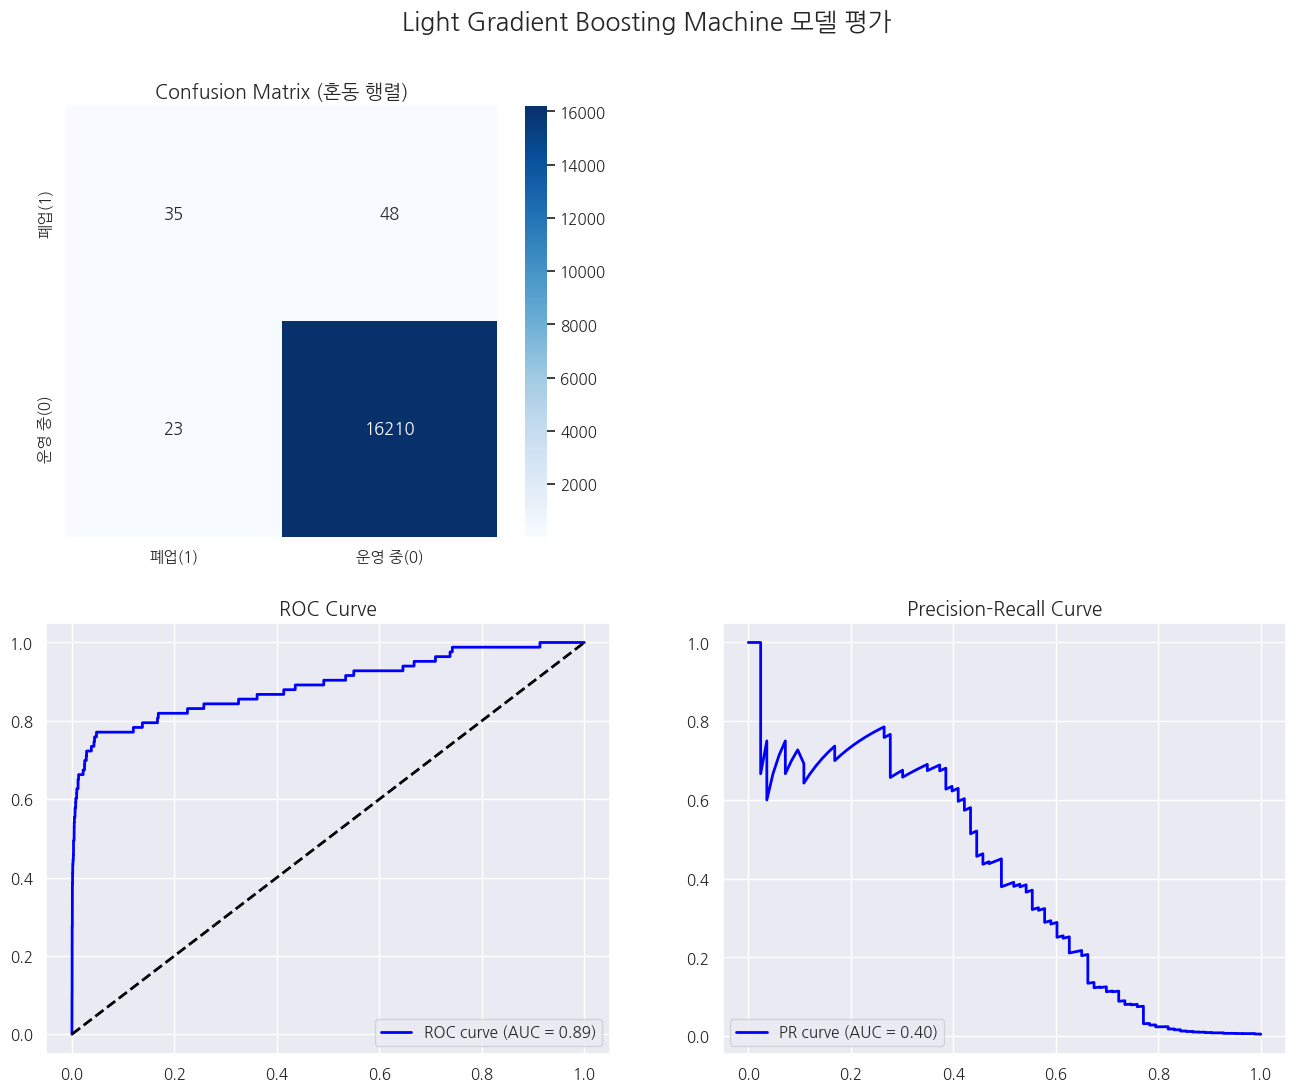

In [17]:
lgb_obj2 = Boost_model('lgbm',df_all,GPU = 'on')
lgb_obj2.evaluation()

In [ ]:
LGBMT = ModelTuner('lgbm',X_train, X_test,y_train,y_test)
LGBMT.run()

### Exreme Gradient Boosting

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.8648
정밀도(Precision): 0.6230
재현율(Recall): 0.5205
F1 점수(F1 Score): 0.5672
매튜 상관 계수(MCC): 0.4906



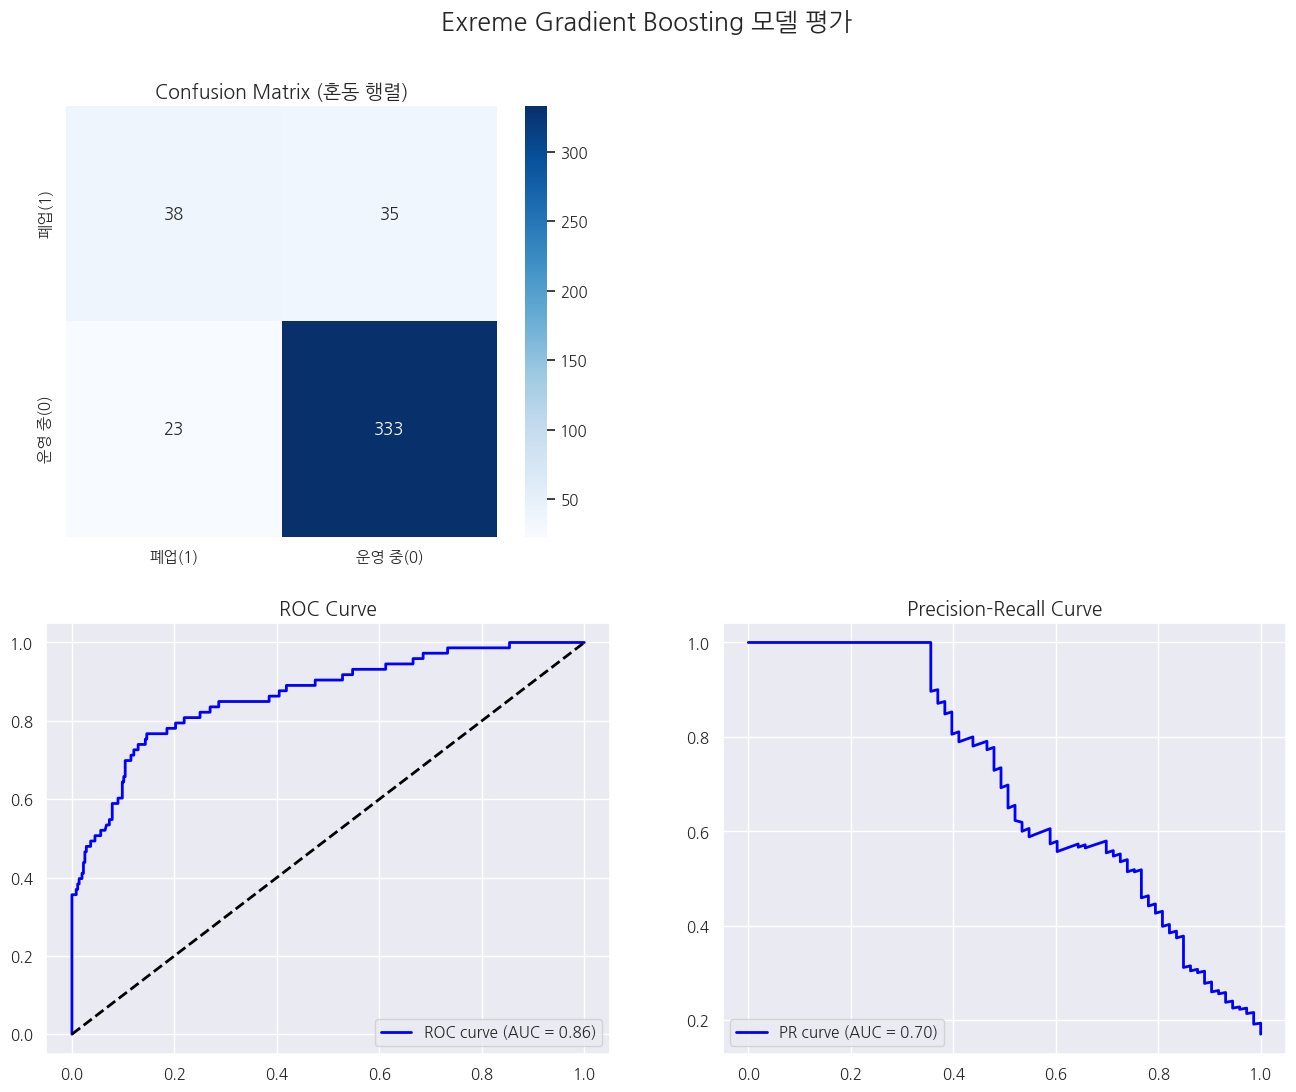

In [14]:
xgb_obj = Boost_model('xgb',df_part, GPU = 'on')
xgb_obj.evaluation()

--- 데이터 인덱스 300번 샘플에 대한 분석을 시작합니다. ---

예측 기여도 텍스트 요약
🎯 가맹점이 폐업할 예측 확률: 0.6894

📊 모델의 평균 예측 기준값 (Base Value): 0.0007

폐업 예측 요인 TOP 5 피쳐:
                         Feature  SHAP Value (기여도)
62       remainder__12개월전_객단가 구간          0.624517
49       remainder__6개월전_매출금액 구간          0.288089
54      remainder__12개월전_매출건수 구간          0.261351
58  remainder__12개월전_유니크 고객 수 구간          0.250523
50      remainder__12개월전_매출금액 구간          0.245834

>>> 4-3. Custom Bar Plot (폐업 예측 긍정 영향 TOP 5)


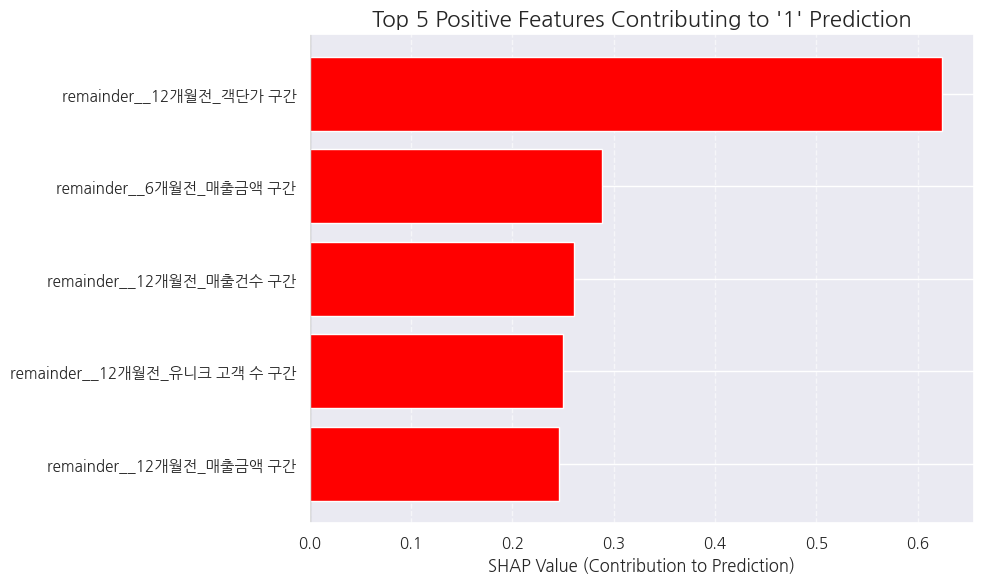


>>>Force Plot (단일 데이터 예측 설명)



>>>Summary Plot (전체 특성 중요도)


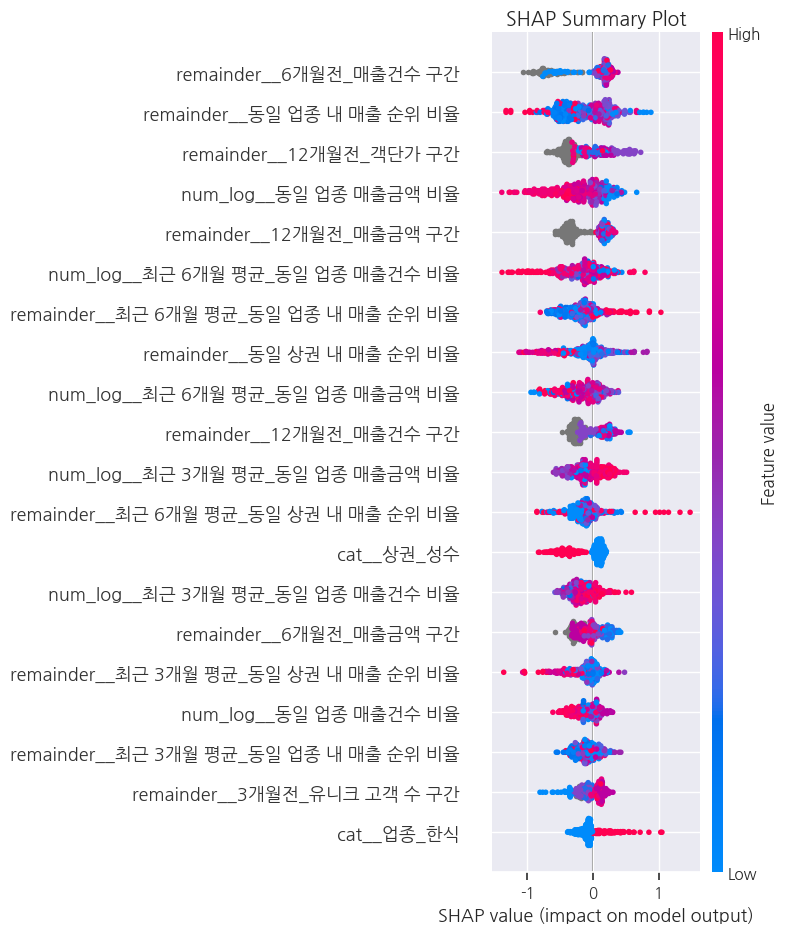

In [15]:
SA2 = ShapAnalysis(xgb_obj.model,df_part)
SA2.single_sample_analysis(index = 300)
SA2.summary_plot()

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.9949
정밀도(Precision): 0.5000
재현율(Recall): 0.5301
F1 점수(F1 Score): 0.5146
매튜 상관 계수(MCC): 0.5123



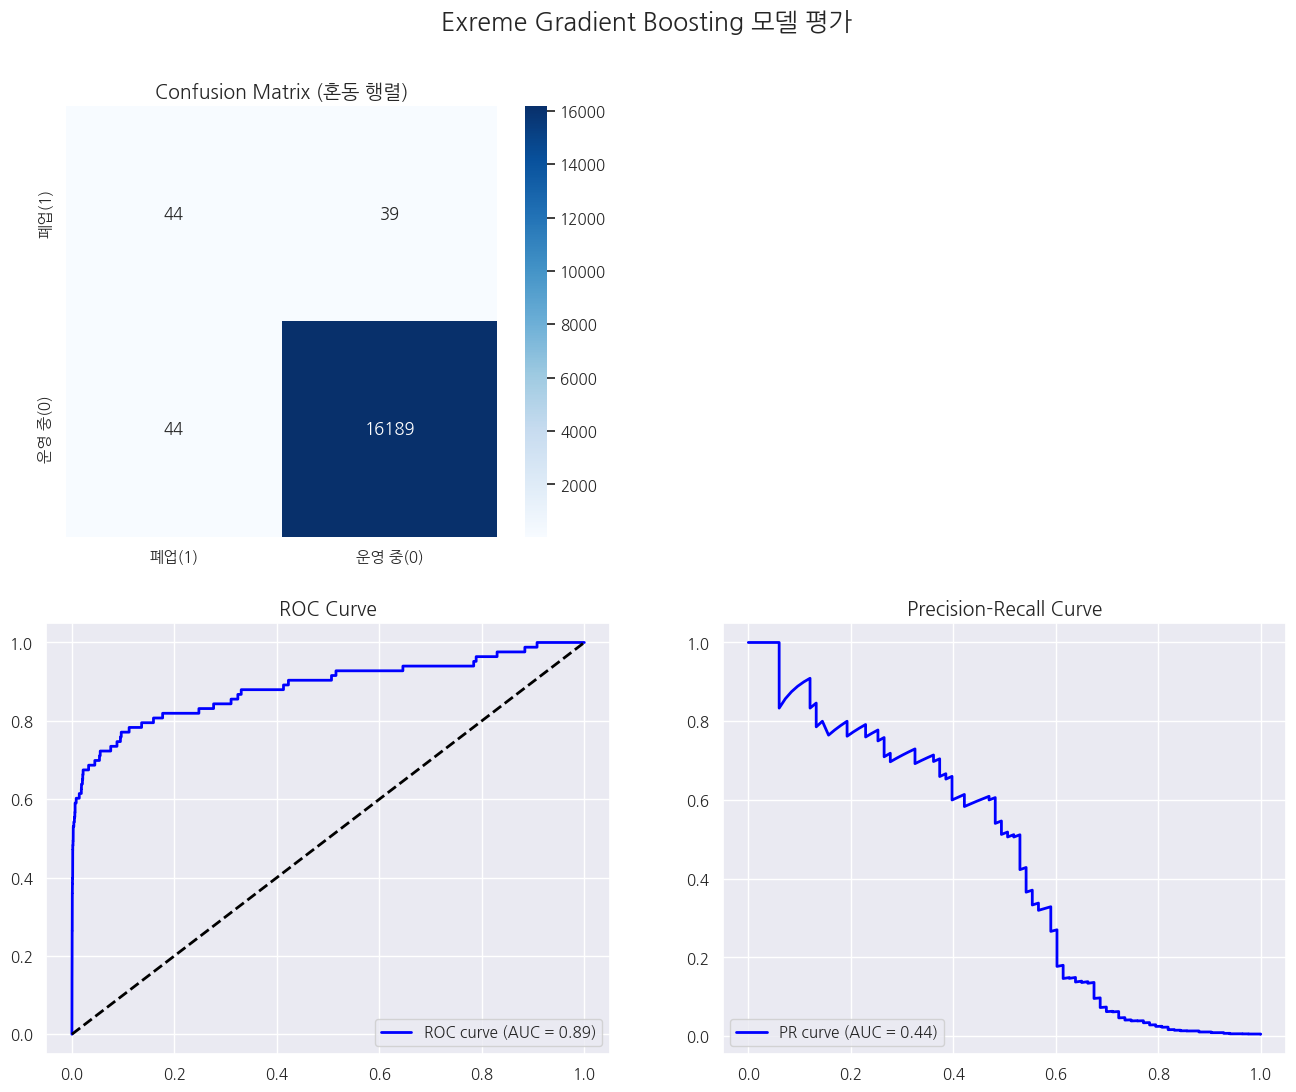

In [18]:
xgb_obj2 = Boost_model('xgb',df_all, GPU = 'on')
xgb_obj2.evaluation()

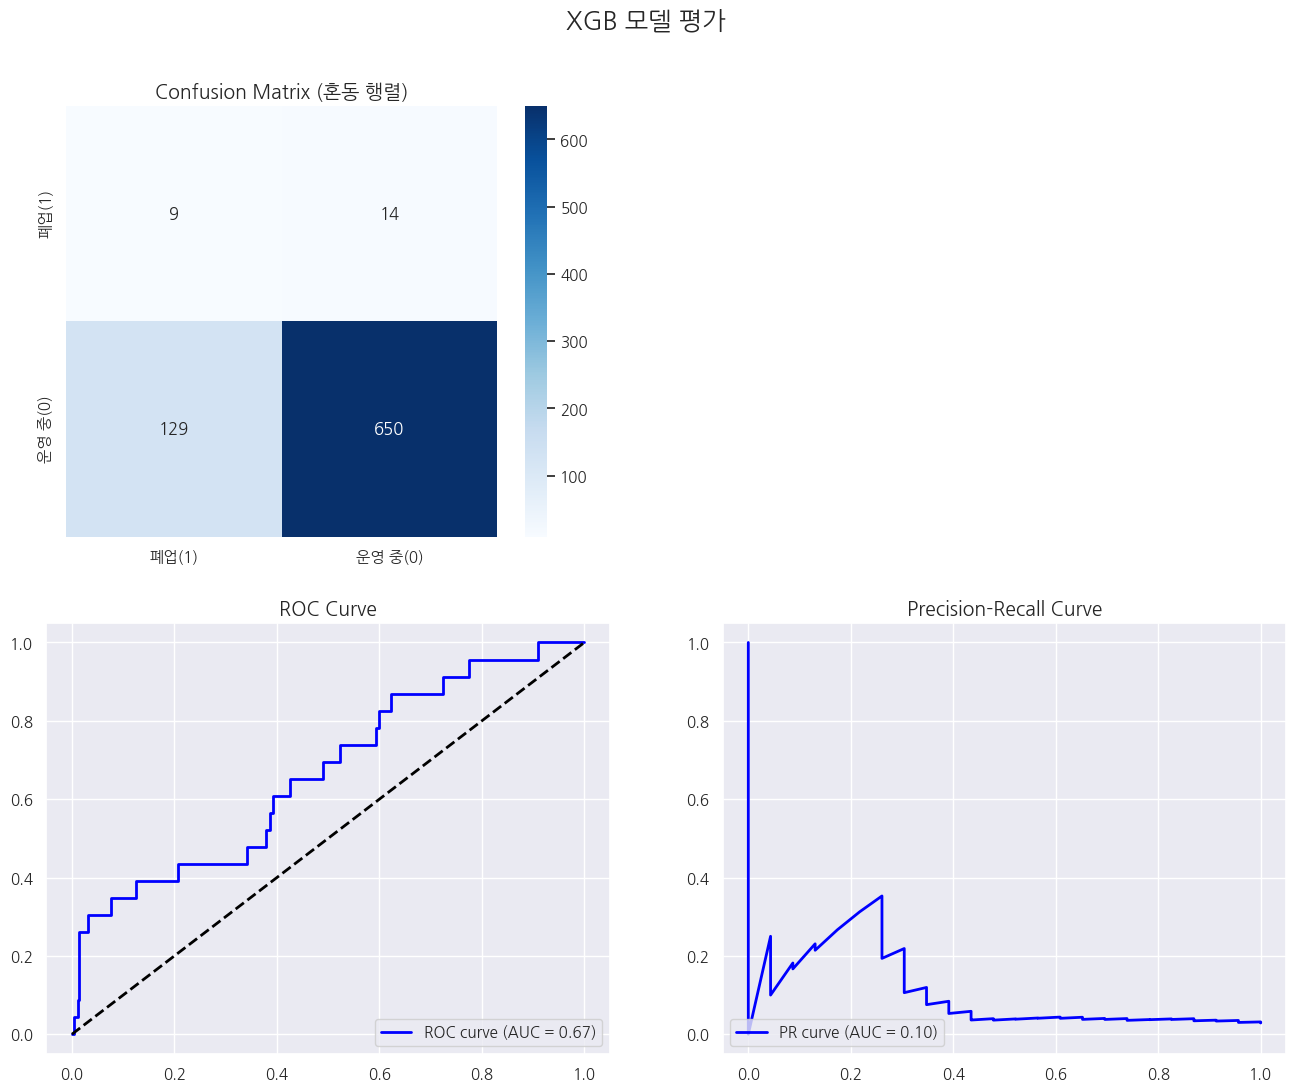

In [ ]:
XGBT = ModelTuner('xgb',X_train, X_test,y_train,y_test) #Xtr_yte
XGBT.run()

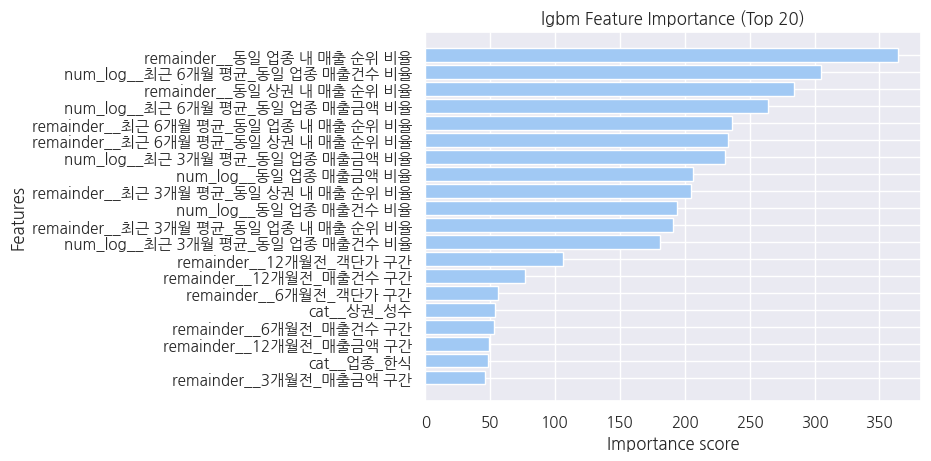

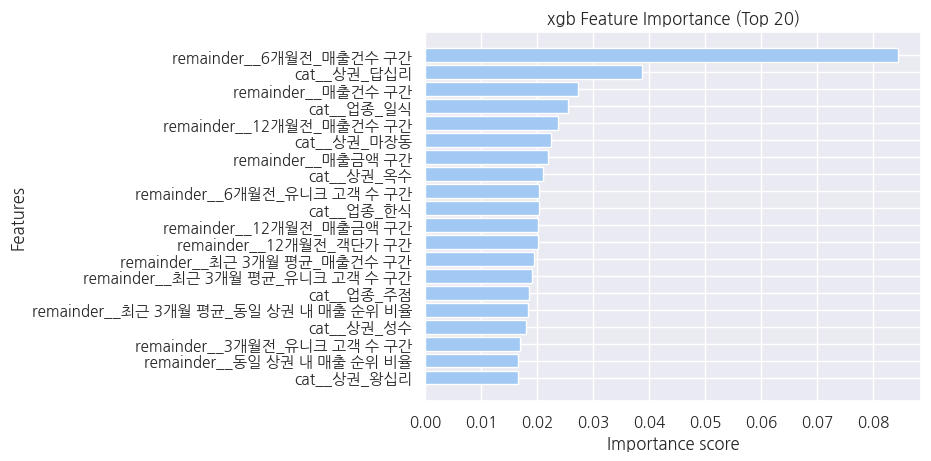

In [15]:
# LightGBM
lgb_obj.plot_feature_importance()

# XGBoost
xgb_obj.plot_feature_importance()

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_spl

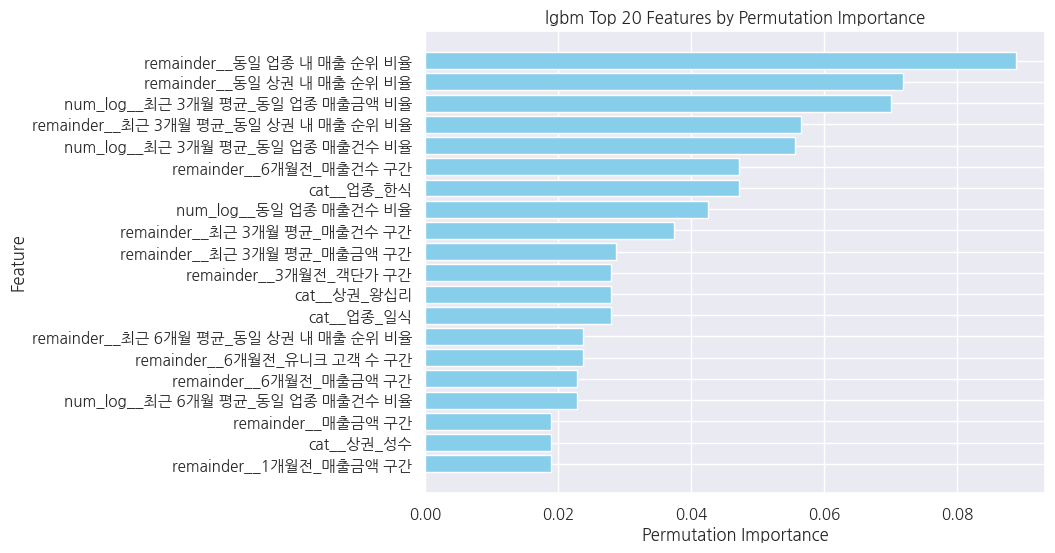

                                  feature  importance
33            remainder__동일 업종 내 매출 순위 비율    0.068914
5        num_log__최근 6개월 평균_동일 업종 매출건수 비율    0.048296
3        num_log__최근 3개월 평균_동일 업종 매출건수 비율    0.041041
34            remainder__동일 상권 내 매출 순위 비율    0.037674
2        num_log__최근 3개월 평균_동일 업종 매출금액 비율    0.036541
49                remainder__6개월전_매출금액 구간    0.027473
0                  num_log__동일 업종 매출금액 비율    0.027110
23                             cat__상권_성수    0.022523
18                             cat__업종_한식    0.022523
46  remainder__최근 6개월 평균_동일 상권 내 매출 순위 비율    0.017850


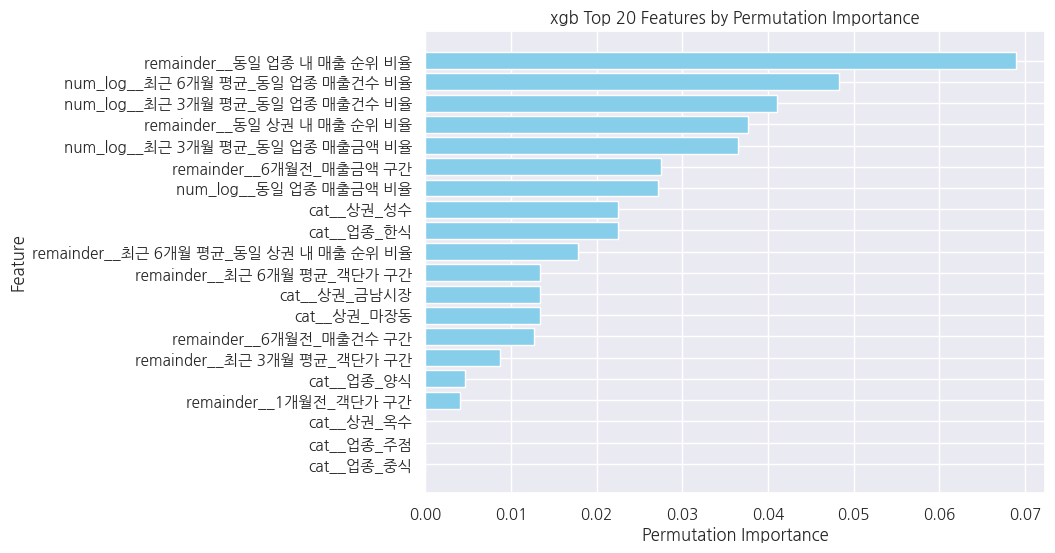

In [16]:
lgb_obj.permutation_importance_plot()
xgb_obj.permutation_importance_plot()

## 비지도 학습

In [ ]:
#final_df,final_df_all,final_df_base,final_df_not

In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples


def kmeans_encoder(final_df):

    final_df_cp = final_df.copy()
    final_df_cp = final_df_cp.fillna(0)

    numerical_features = final_df_cp.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = final_df_cp.select_dtypes(exclude=['int64', 'float64']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
            ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
        ])

    final_df_cp = preprocessor.fit_transform(final_df_cp)
    return final_df_cp


In [24]:
#final_df_prc = kmeans_encoder(final_df)
final_df_prc = kmeans_encoder(final_df_all)
#df_base_prc = kmeans_encoder(final_df_base)
#df_not_prc = kmeans_encoder(final_df_not)

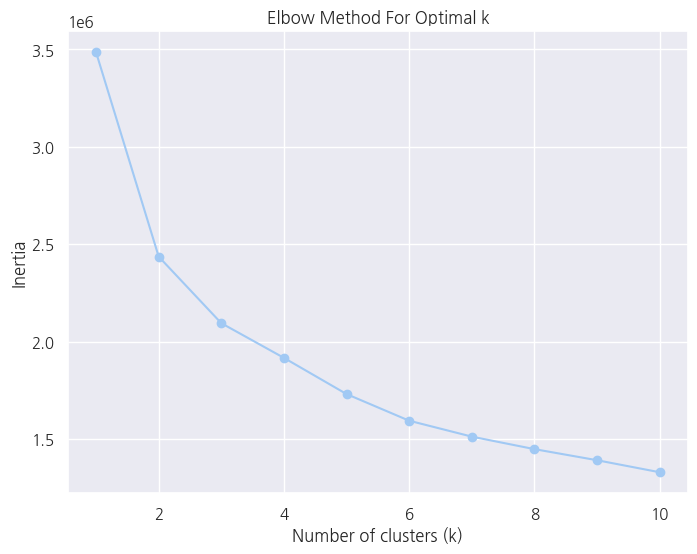

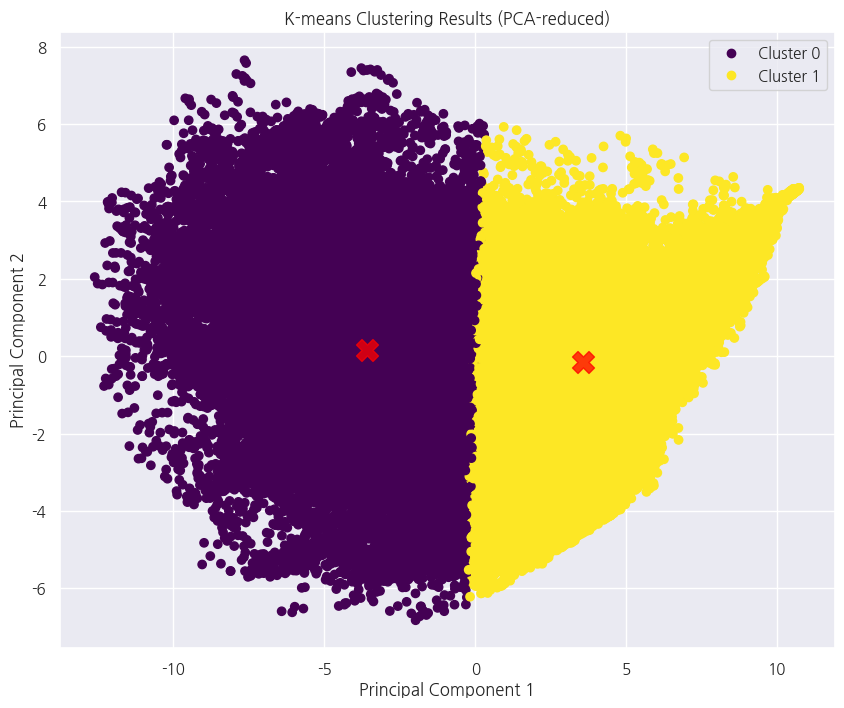

In [25]:
# k-means clustering

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(final_df_prc)
    inertia.append(kmeans.inertia_)

# Elbow Method 
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(final_df_prc)

#PCA를 사용하여 2차원으로 차원 축소 후 시각화
#클러스터의 중심을 빨간색 'X'로 표시
pca = PCA(n_components=2)
principal_components = pca.fit_transform(final_df_prc)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(principal_components.iloc[:, 0], principal_components.iloc[:, 1], c=cluster_labels, cmap='viridis', marker='o')

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers.iloc[:, 0], centers.iloc[:, 1], c='red', s=250, alpha=0.75, marker='X')
plt.title('K-means Clustering Results (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(optimal_k)])
plt.grid(True)
plt.show()

In [26]:
len((principal_components.iloc[:, 0]))

81577

For n_clusters = 2, the average silhouette_score is : 0.2513


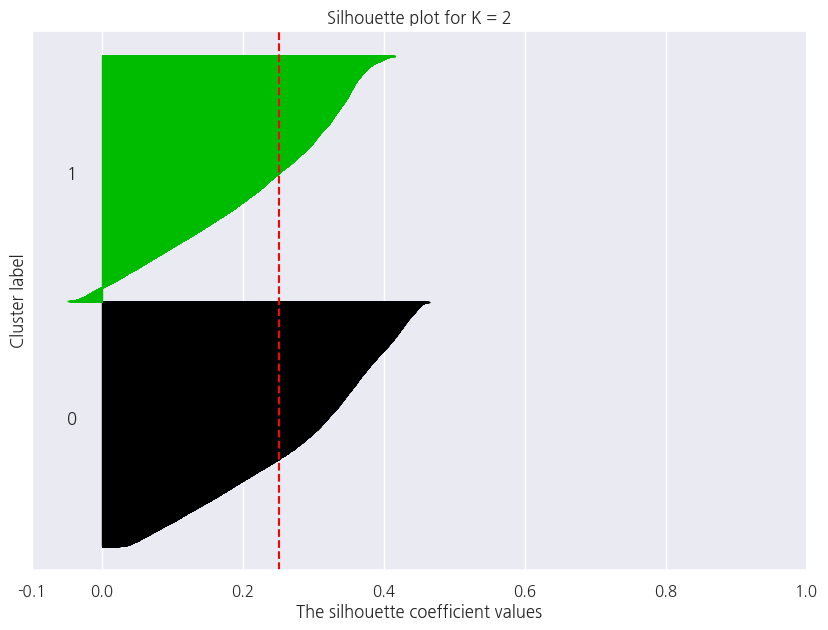

KeyboardInterrupt: 

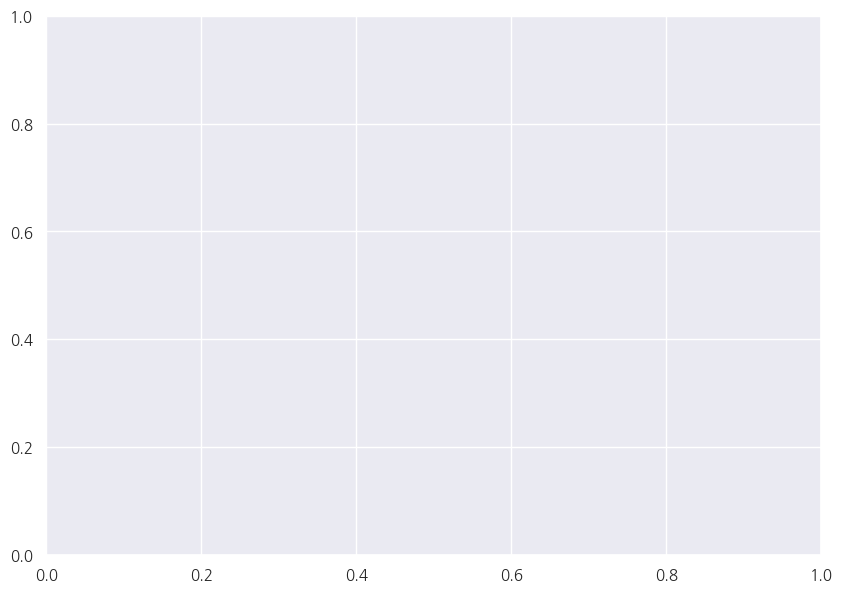

In [27]:
#silhouette score

for k in range(2, 11):

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)


    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(final_df_prc)
    silhouette_vals = silhouette_samples(final_df_prc, kmeans.labels_)
    avg_silhouette_score = silhouette_score(final_df_prc, kmeans.labels_)
    print(f"For n_clusters = {k}, the average silhouette_score is : {avg_silhouette_score:.4f}")
    
    y_lower = 10  
    

    for c_num in range(k):

        cluster_silhouette_vals = silhouette_vals[kmeans.labels_ == c_num]
        cluster_silhouette_vals.sort()
        
        cluster_size = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + cluster_size
        color = cm.nipy_spectral(float(c_num) / k)
        
        ax.barh(range(y_lower, y_upper), 
                cluster_silhouette_vals, 
                facecolor=color, 
                edgecolor=color,
                height=1.0)
        
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(c_num))
        y_lower = y_upper + 10  # 다음 클러스터와의 여백

    ax.set_title(f"Silhouette plot for K = {k}")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")


    ax.axvline(x=avg_silhouette_score, color="red", linestyle="--")
    
    ax.set_yticks([])  
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

In [28]:
final_df_prc['cluster'] = cluster_labels

# 각 클러스터별로 모든 피쳐의 평균값을 계산하여 비교
cluster_feature_means = final_df_prc.groupby('cluster').mean()

# 보기 쉽게 행과 열을 전환(.T)하여 출력
print(cluster_feature_means.T)

cluster                    0         1
num__매출금액 구간       -0.727682  0.723359
num__매출건수 구간       -0.736787  0.732411
num__유니크 고객 수 구간   -0.750865  0.746405
num__객단가 구간        -0.037976  0.037751
num__동일 업종 매출금액 비율  0.628118 -0.624387
...                      ...       ...
cat__상권_신금호         0.034524  0.036788
cat__상권_옥수          0.030393  0.033121
cat__상권_왕십리         0.188236  0.190540
cat__상권_한양대         0.122163  0.052310
cat__상권_행당          0.048098  0.058836

[64 rows x 2 columns]


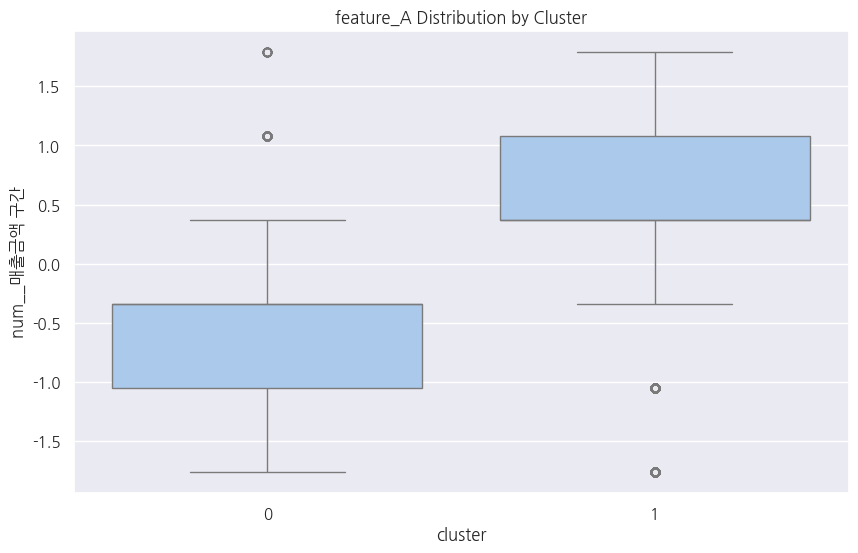

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num__매출금액 구간', data=final_df_prc)
plt.title('feature_A Distribution by Cluster')
plt.show()

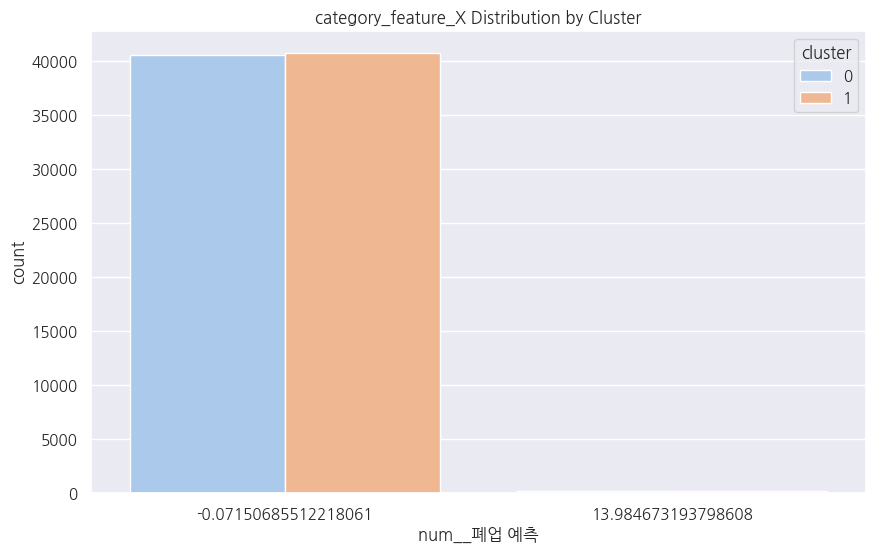

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__폐업 예측', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

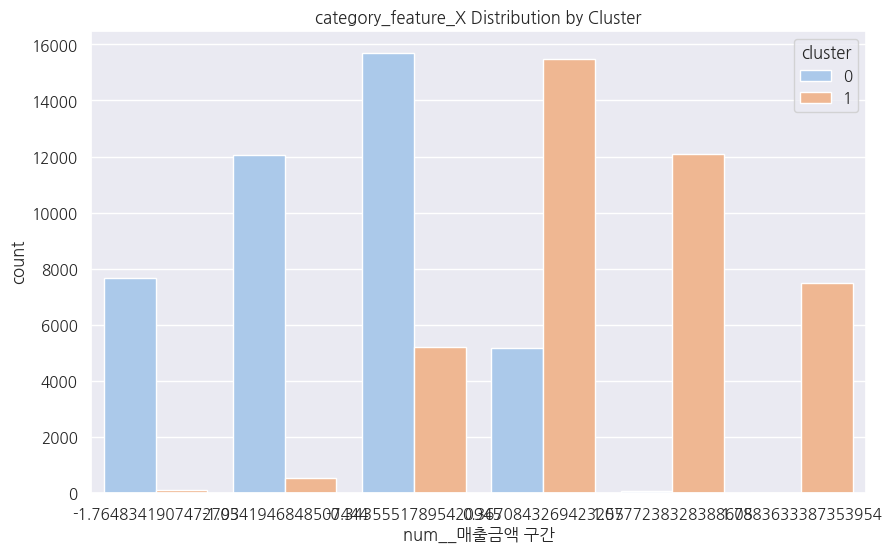

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__매출금액 구간', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

### Deep Learning